# External Data — Loading and Validation

This notebook loads, cleans and validates all external datasets required for the SVAR.

| Variable | File | Source | Frequency |
|---|---|---|---|
| UAH/USD exchange rate | uah_usd.csv | Stooq | Monthly |
| Brent crude oil (USD/bbl) | brent.csv | FRED / EIA | Monthly |
| ECB deposit rate (%) | ecb_rate.csv | FRED / ECB | Monthly |
| EA industrial production YoY (%) | ea_ip.csv | FRED / Eurostat | Monthly |
| Ukraine industry value added growth (%) | ukr_ip.csv | World Bank (interpolated) | Monthly |

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd           = Path.cwd()
DATA_EXTERNAL = cwd.parent / "data" / "data_external"
OUTPUTS       = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

START = "2005-01-01"
END   = "2025-12-31"

print("data_external contents:")
for f in sorted(DATA_EXTERNAL.iterdir()):
    print(f"  {f.name}")

data_external contents:
  brent.csv
  ea_ip.csv
  ecb_rate.csv
  external_data.csv
  uah_usd.csv
  uahusd_m.csv
  ukr_ip.csv


## 1. Load all series

In [2]:
def load_series(filename, col=None):
    path = DATA_EXTERNAL / filename
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    df.index = df.index.to_period("M").to_timestamp()
    s = df.iloc[:, 0] if col is None else df[col]
    s = s.loc[START:END]
    return s

uah_usd  = load_series("uah_usd.csv")
brent    = load_series("brent.csv")
ecb_rate = load_series("ecb_rate.csv")
ea_ip    = load_series("ea_ip.csv")
ukr_ip   = load_series("ukr_ip.csv")

print(f"{'Variable':<12} {'Obs':>5} {'Start':>12} {'End':>12} {'Mean':>8} {'Std':>8}")
print("-" * 62)
for name, s in [("uah_usd", uah_usd), ("brent", brent), ("ecb_rate", ecb_rate),
                ("ea_ip", ea_ip), ("ukr_ip", ukr_ip)]:
    n = s.dropna()
    print(f"{name:<12} {len(n):>5} {str(n.index.min().date()):>12} "
          f"{str(n.index.max().date()):>12} {n.mean():>8.2f} {n.std():>8.2f}")

Variable       Obs        Start          End     Mean      Std
--------------------------------------------------------------
uah_usd        241   2005-01-01   2025-12-01    18.70    12.38
brent          252   2005-01-01   2025-12-01    75.78    23.59
ecb_rate       252   2005-01-01   2025-12-01     0.78     1.41
ea_ip          226   2005-01-01   2023-10-01     0.62     6.45
ukr_ip         252   2005-01-01   2025-12-01    -2.72     9.28


## 2. Assemble master external dataset

In [3]:
monthly_idx = pd.date_range(START, END, freq="MS")

external = pd.DataFrame({
    "uah_usd":  uah_usd.reindex(monthly_idx),
    "brent":    brent.reindex(monthly_idx),
    "ecb_rate": ecb_rate.reindex(monthly_idx),
    "ea_ip":    ea_ip.reindex(monthly_idx),
    "ukr_ip":   ukr_ip.reindex(monthly_idx),
}, index=monthly_idx)
external.index.name = "date"

print("Master dataset shape:", external.shape)
print("\nMissing values:")
print(external.isnull().sum())

external.to_csv(DATA_EXTERNAL / "external_data.csv")
print("\nSaved → external_data.csv")

Master dataset shape: (252, 5)

Missing values:
uah_usd     11
brent        0
ecb_rate     0
ea_ip       26
ukr_ip       0
dtype: int64

Saved → external_data.csv


## 3. Visual inspection

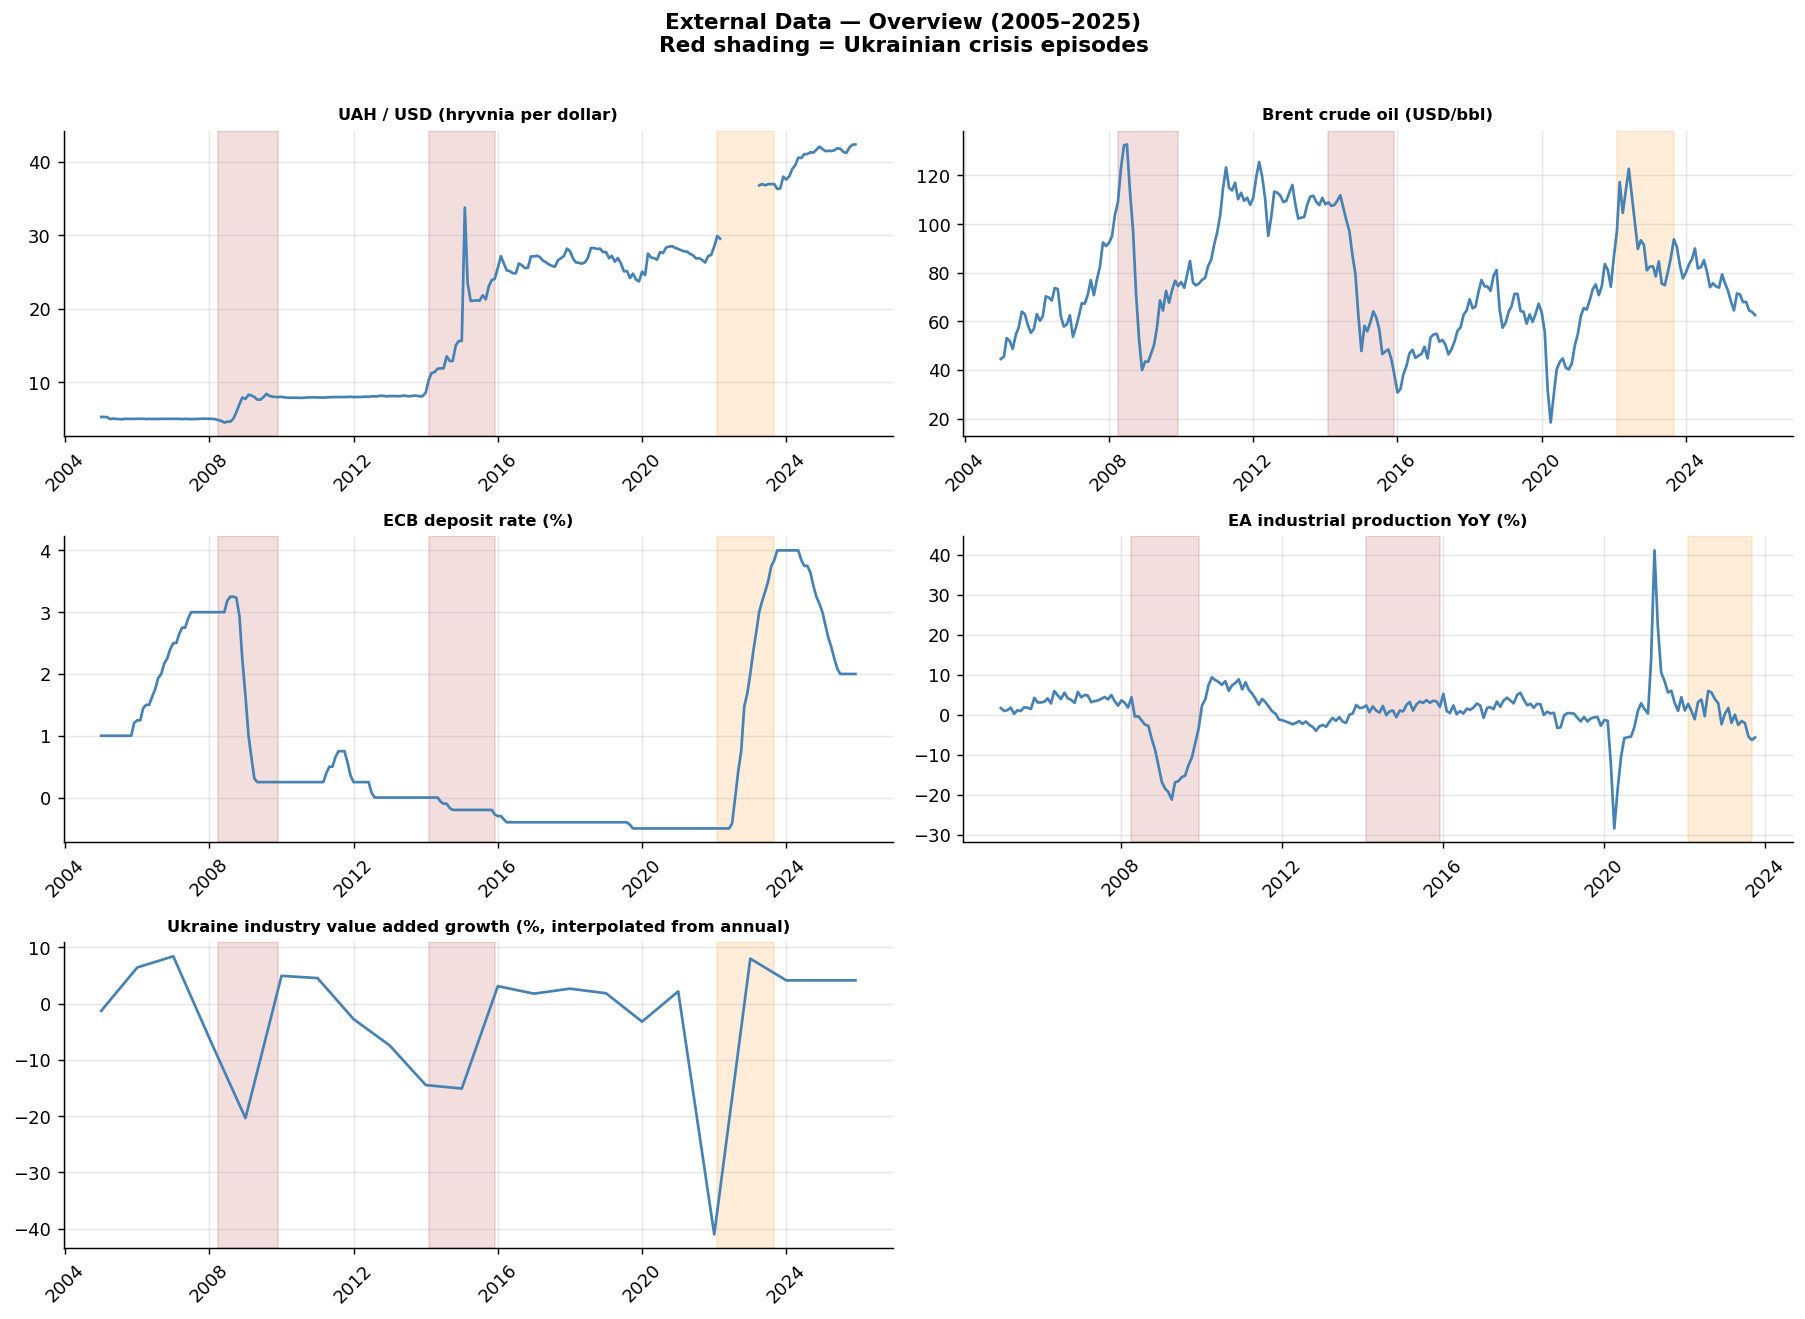

Figure saved.


In [4]:
TITLES = {
    "uah_usd":  "UAH / USD (hryvnia per dollar)",
    "brent":    "Brent crude oil (USD/bbl)",
    "ecb_rate": "ECB deposit rate (%)",
    "ea_ip":    "EA industrial production YoY (%)",
    "ukr_ip":   "Ukraine industry value added growth (%, interpolated from annual)",
}

REGIMES = [
    ("2008-04", "2009-12", "firebrick",  0.15),
    ("2014-02", "2015-12", "firebrick",  0.15),
    ("2022-02", "2023-09", "darkorange", 0.15),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(external.columns):
    ax = axes[i]
    for start, end, color, alpha in REGIMES:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
    ax.plot(external.index, external[col], lw=1.5, color="steelblue")
    ax.set_title(TITLES[col], fontsize=9, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.tick_params(axis="x", rotation=45)

axes[-1].set_visible(False)

plt.suptitle("External Data — Overview (2005–2025)\nRed shading = Ukrainian crisis episodes",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / "fig4_external_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Note on Ukraine industrial production

The `ukr_ip` series is the World Bank annual industry value added growth (%), linearly interpolated to monthly frequency. This is a standard approach when monthly data is unavailable — it preserves the annual signal while providing the monthly observations required for the SVAR.

The key episodes are visible in the annual data:
- **2009**: -20.3% (GFC + hryvnia collapse)
- **2014-2015**: -14.5% and -15.1% (Crimea annexation, Donbas conflict)
- **2022**: -41.0% (full-scale invasion)

These correspond exactly to the devaluation episodes identified in Part A.